## Sync Processing

In [ ]:
import time

def brew_coffee():
    print("Brewing a fresh cup of coffee...")   
    time.sleep(3)  # Simulate the time taken to brew coffee
    print("Your coffee is ready!")

def toast_bread():
    print("Toasting bread...")
    time.sleep(5)  # Simulate the time taken to toast bread
    print("Your toast is ready!")

def main():
    start = time.time()
    brew_coffee()
    toast_bread()

    end = time.time()
    print(f"Total time taken: {end - start:.2f} seconds")

if __name__ == "__main__":
    main()


## Async Processing

In [ ]:
import time
import asyncio

import nest_asyncio
nest_asyncio.apply()

async def brew_coffee():
    print("Brewing a fresh cup of coffee...")   
    await asyncio.sleep(3)  # Simulate the time taken to brew coffee
    print("Your coffee is ready!")

async def toast_bread():
    print("Toasting bread...")
    await asyncio.sleep(5)  # Simulate the time taken to toast bread
    print("Your toast is ready!")

async def main():
    start = time.time()
    coffee = brew_coffee()
    toast = toast_bread()
    result= await asyncio.gather(coffee, toast)
    end = time.time()
    print(f"Total time taken: {end - start:.2f} seconds")


asyncio.run(main())

## Set ENV Vriables

In [ ]:
from dotenv import load_dotenv
load_dotenv()

## Autogen

In [ ]:
from autogen_agentchat.agents import AssistantAgent

from autogen_ext.models.openai import OpenAIChatCompletionClient
model_client = OpenAIChatCompletionClient(model="gpt-4o-mini")

agent = AssistantAgent(
    name="agent1",
    model_client=model_client,
    system_message="You are a helpful assistant. You give short, humorous answers.",
    model_client_stream=True
)

response = await agent.run(task="what is capital of UK?")
print(response)
print(response.messages[0].content)
print(response.messages[-1].content)

## Autogen Ecosystem

![components](https://github.com/microsoft/autogen/raw/main/autogen-landing.jpg)


|Component|Key Role|
|-------------------|------------------------------------|
|Core|Async, even-drive foundation for scalable agents|
|AgentChat|Simplifies building conversational agents. Predefined agent roles (AssistantAgent,UserProxyAgent|
|Extensions|Adds external tools/apis to agent|
|Your App| Custom applications (e.g. chatbots, assistants)|
|Magnetic-One|A pre-built app that demonstrates multi-agent collaboration. A reference.|
|Bench|Tests agent performance under load|
|Studio|visual tool for desiging agent workflows.|

## Models

You can use "autogen-ext[grpc,mcp,ollama,openai,azure]>=0.7.5" to add extensions like openai, ollama, azure and many more to your application.

Openai models can be accessed as below:
```python
from autogen_ext.models.openai import OpenAIChatCompletionClient

openai_model_client = OpenAIChatCompletionClient(
    model="gpt-4o-2024-08-06",
    # api_key="sk-...", # Optional if you have an OPENAI_API_KEY environment variable set.
)

```

#### Azure OpenAI Model

```python
from autogen_core.models import UserMessage
from autogen_ext.auth.azure import AzureTokenProvider
from autogen_ext.models.openai import AzureOpenAIChatCompletionClient
from azure.identity import DefaultAzureCredential

# Create the token provider
token_provider = AzureTokenProvider(
    DefaultAzureCredential(),
    "https://cognitiveservices.azure.com/.default",
)

az_model_client = AzureOpenAIChatCompletionClient(
    azure_deployment="{your-azure-deployment}",
    model="{model-name, such as gpt-4o}",
    api_version="2024-06-01",
    azure_endpoint="https://{your-custom-endpoint}.openai.azure.com/",
    azure_ad_token_provider=token_provider,  # Optional if you choose key-based authentication.
    # api_key="sk-...", # For key-based authentication.
)

result = await az_model_client.create([UserMessage(content="What is the capital of France?", source="user")])
print(result)
await az_model_client.close()

```

#### Azure AI Foundry
Azure AI Foundry (previously known as Azure AI Studio) offers models hosted on Azure. To use those models, you use the AzureAIChatCompletionClient.

```python
import os

from autogen_core.models import UserMessage
from autogen_ext.models.azure import AzureAIChatCompletionClient
from azure.core.credentials import AzureKeyCredential

client = AzureAIChatCompletionClient(
    model="Phi-4",
    endpoint="https://models.github.ai/inference",
    # To authenticate with the model you will need to generate a personal access token (PAT) in your GitHub settings.
    # Create your PAT token by following instructions here: https://docs.github.com/en/authentication/keeping-your-account-and-data-secure/managing-your-personal-access-tokens
    credential=AzureKeyCredential(os.environ["GITHUB_TOKEN"]),
    model_info={
        "json_output": False,
        "function_calling": False,
        "vision": False,
        "family": "unknown",
        "structured_output": False,
    },
)

result = await client.create([UserMessage(content="What is the capital of France?", source="user")])
print(result)
await client.close()

```


#### Gemini Models

```python
from autogen_core.models import UserMessage
from autogen_ext.models.openai import OpenAIChatCompletionClient

model_client = OpenAIChatCompletionClient(
    model="gemini-2.5-flash",
    # api_key="GEMINI_API_KEY",
)

response = await model_client.create([UserMessage(content="What is the capital of France?", source="user")])
print(response)
await model_client.close()
```

#### Ollama Models

```python
from autogen_core.models import UserMessage
from autogen_ext.models.ollama import OllamaChatCompletionClient

# Assuming your Ollama server is running locally on port 11434.
ollama_model_client = OllamaChatCompletionClient(model="llama3.2")

response = await ollama_model_client.create([UserMessage(content="What is the capital of France?", source="user")])
print(response)
await ollama_model_client.close()

```

#### Log Model Calls

```python
import logging

from autogen_core import EVENT_LOGGER_NAME

logging.basicConfig(level=logging.WARNING)
logger = logging.getLogger(EVENT_LOGGER_NAME)
logger.addHandler(logging.StreamHandler())
logger.setLevel(logging.INFO)

```

#### Open Router Model Call

In [13]:
import os
from dotenv import load_dotenv
from autogen_core.models import UserMessage
from autogen_agentchat.agents import AssistantAgent
from autogen_ext.models.openai import OpenAIChatCompletionClient
load_dotenv()

openrouter_api_key=os.getenv("OPENROUTER_API_KEY")

openrouter_model = OpenAIChatCompletionClient(
    base_url="https://openrouter.ai/api/v1",
    model="openai/gpt-oss-20b:free",
    api_key=openrouter_api_key,
    model_info={
        "family": "openai",
        "vision": False,
        "function_calling": True,
        "json_output": False,
    }
)

assistant1 = AssistantAgent(
    name="assistant1",
    model_client=openrouter_model,
    system_message="You are a helpful assistant that can see images and answer questions about them.",
)

response = await assistant1.run(
    task="What is capital of France?")

response.messages[-1].content


'The capital of France is **Paris**.'

## Messages
In AutoGen AgentChat, messages facilitate communication and information exchange with other agents, orchestrators, and applications

AgentChat supports many message types for agent-to-agent communication. They belong to subclasses of the base class BaseChatMessage. Concrete subclasses covers basic text and multimodal communication, such as TextMessage and MultiModalMessage.

AgentChat also supports the concept of events - messages that are internal to an agent. These messages are used to communicate events and information on actions within the agent itself, and belong to subclasses of the base class BaseAgentEvent.

#### TextMessage

```python
from autogen_agentchat.messages import TextMessage

text_message = TextMessage(content="Hello, world!", source="User")

```

#### MultiModalMessage
Message handling audio, image, video and text.

The image features a city street surrounded by tall buildings, creating a canyon-like effect. The architecture is a mix of modern and older styles, typical of a bustling urban environment. The street is relatively narrow, and there are cars, suggesting busy traffic. The overall tone is moody and somewhat desaturated, giving it a dramatic atmosphere.



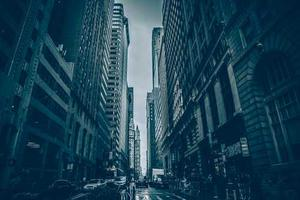

In [24]:
from io import BytesIO

import requests
from autogen_agentchat.messages import MultiModalMessage
from autogen_core import Image as AGImage
from PIL import Image

from autogen_agentchat.agents import AssistantAgent
from autogen_ext.models.openai import OpenAIChatCompletionClient

pil_image = Image.open(BytesIO(requests.get("https://picsum.photos/300/200").content))
img = AGImage(pil_image)
multi_modal_message = MultiModalMessage(content=["Can you describe the content of this image?", img], 
                                        source="User")



model = OpenAIChatCompletionClient(model="gpt-4o")
assistant_with_vision = AssistantAgent(
    name="assistant_with_vision",
    model_client=model,
    system_message="You are a helpful assistant that can see images and answer questions about them.",
)

response = await assistant_with_vision.run(
    task=multi_modal_message
)

print(response.messages[-1].content)

img


#### Custom Message Type
You can create custom message types by subclassing the base class BaseChatMessage or BaseAgentEvent. 

#### Streaming Message

In [ ]:
async def assistant_run_stream() -> None:
    # Option 1: read each message from the stream (as shown in the previous example).
    # async for message in agent.run_stream(task="Find information on AutoGen"):
    #     print(message)

    # Option 2: use Console to print all messages as they appear.
    await Console(
        agent.run_stream(task="Find information on AutoGen"),
        output_stats=True,  # Enable stats printing.
    )


# Use asyncio.run(assistant_run_stream()) when running in a script.
await assistant_run_stream()

##### Youtube Transcript

In [25]:
import asyncio
from autogen_agentchat.agents import AssistantAgent
from autogen_ext.models.openai import OpenAIChatCompletionClient
from autogen_agentchat.messages import TextMessage
from youtube_transcript_api import YouTubeTranscriptApi

# 1. Define the tool function
def get_youtube_transcript(video_url: str) -> str:
    """
    Retrieves the transcript of a YouTube video given its URL.
    """
    try:
        video_id = video_url.split("v=")[1].split("&")[0]
        transcript_list = YouTubeTranscriptApi.get_transcript(video_id)
        # Combine the list of dictionaries into a single string
        full_text = " ".join([item['text'] for item in transcript_list])
        return full_text
    except Exception as e:
        return f"Error retrieving transcript: {str(e)}"

async def main():
    # 2. Initialize the Model
    model = OpenAIChatCompletionClient(model="gpt-4o")

    # 3. Initialize the Agent with the Tool
    # We pass the function directly into the 'tools' list.
    assistant = AssistantAgent(
        name="video_assistant",
        model_client=model,
        system_message="You are a helpful assistant. Use tools to fetch video transcripts when asked.",
        tools=[get_youtube_transcript] 
    )

    # 4. Run the Agent
    # We ask a question that requires the tool.
    video_url = "https://www.youtube.com/watch?v=dQw4w9WgXcQ" # Rick Roll example
    user_message = TextMessage(
        content=f"Get the transcript for this video and summarize it: {video_url}", 
        source="User"
    )

    response = await assistant.run(task=user_message)

    print(response.messages[-1].content)

# Run the async main function
if __name__ == "__main__":
    asyncio.run(main())

ModuleNotFoundError: No module named 'youtube_transcript_api'

## Agents

AutoGen AgentChat provides a set of preset Agents, each with variations in how an agent might respond to messages. All agents share the following attributes and methods:

name: The unique name of the agent.

description: The description of the agent in text.

run: The method that runs the agent given a task as a string or a list of messages, and returns a TaskResult. Agents are expected to be stateful and this method is expected to be called with new messages, not complete history.

run_stream: Same as run() but returns an iterator of messages that subclass BaseAgentEvent or BaseChatMessage followed by a TaskResult as the last item.

#### Assistant Agent
AssistantAgent is a built-in agent that uses a language model and has the ability to use tools.

In [ ]:
import asyncio
from autogen_agentchat.agents import AssistantAgent
from autogen_agentchat.messages import StructuredMessage
from autogen_agentchat.ui import Console
from autogen_ext.models.openai import OpenAIChatCompletionClient

# Define a tool that searches the web for information.
# For simplicity, we will use a mock function here that returns a static string.
async def web_search(query: str) -> str:
    """Find information on the web"""
    return "AutoGen is a programming framework for building multi-agent applications."


# Create an agent that uses the OpenAI GPT-4o model.
model_client = OpenAIChatCompletionClient(
    model="gpt-4.1-nano",
    # api_key="YOUR_API_KEY",
)
agent = AssistantAgent(
    name="assistant",
    model_client=model_client,
    tools=[web_search],
    system_message="Use tools to solve tasks.",
)

# Use asyncio.run(agent.run(...)) when running in a script.
# result = await asyncio.run(agent.run(task="Find information on AutoGen"))
result = await agent.run(task="Find information on AutoGen")
print(result.messages[-1].content)

In [ ]:
from io import BytesIO

import PIL
import requests
from autogen_agentchat.messages import MultiModalMessage
from autogen_core import Image

# Create a multi-modal message with random image and text.
pil_image = PIL.Image.open(BytesIO(requests.get("https://picsum.photos/300/200").content))
img = Image(pil_image)
multi_modal_message = MultiModalMessage(content=["Can you describe the content of this image?", img], source="user")
img

In [ ]:
# Use asyncio.run(...) when running in a script.
result = await agent.run(task=multi_modal_message)
print(result.messages[-1].content)  # type: ignore

#### Defining Tool

In [ ]:
from autogen_core.tools import FunctionTool


# Define a tool using a Python function.
async def web_search_func(query: str) -> str:
    """Find information on the web"""
    return "AutoGen is a programming framework for building multi-agent applications."


# This step is automatically performed inside the AssistantAgent if the tool is a Python function.
web_search_function_tool = FunctionTool(web_search_func, description="Find information on the web")
# The schema is provided to the model during AssistantAgent's on_messages call.
web_search_function_tool.schema


#### Using MCP Server Workbench

In [ ]:
from autogen_agentchat.agents import AssistantAgent
from autogen_agentchat.messages import TextMessage
from autogen_ext.models.openai import OpenAIChatCompletionClient
from autogen_ext.tools.mcp import McpWorkbench, StdioServerParams

# Get the fetch tool from mcp-server-fetch.
fetch_mcp_server = StdioServerParams(command="uvx", args=["mcp-server-fetch"], timeout=120)

# Create an MCP workbench which provides a session to the mcp server.
async with McpWorkbench(fetch_mcp_server) as workbench:  # type: ignore
    # Create an agent that can use the fetch tool.
    model_client = OpenAIChatCompletionClient(model="gpt-4.1-nano")
    fetch_agent = AssistantAgent(
        name="fetcher", model_client=model_client, workbench=workbench, reflect_on_tool_use=True
    )

    # Let the agent fetch the content of a URL and summarize it.
    result = await fetch_agent.run(task="Summarize the content of https://oauthapp.azurewebsites.net")
    assert isinstance(result.messages[-1], TextMessage)
    print(result.messages[-1].content)

    # Close the connection to the model client.
    await model_client.close()


#### Parallel Tool Calls

In [ ]:
model_client_no_parallel_tool_call = OpenAIChatCompletionClient(
    model="gpt-4o",
    parallel_tool_calls=False,  # type: ignore
)
agent_no_parallel_tool_call = AssistantAgent(
    name="assistant",
    model_client=model_client_no_parallel_tool_call,
    tools=[web_search],
    system_message="Use tools to solve tasks.",
)

#### Tool Iteration

In [ ]:
agent_loop = AssistantAgent(
    name="assistant_loop",
    model_client=model_client_no_parallel_tool_call,
    tools=[web_search],
    system_message="Use tools to solve tasks.",
    max_tool_iterations=10,  # At most 10 iterations of tool calls before stopping the loop.
)

#### Structuring the Output (custom message type)

In [27]:
from typing import Literal
from autogen_agentchat.agents import AssistantAgent
from autogen_agentchat.messages import StructuredMessage
from autogen_agentchat.ui import Console
from autogen_ext.models.openai import OpenAIChatCompletionClient
from pydantic import BaseModel


# The response format for the agent as a Pydantic base model.
class AgentResponse(BaseModel):
    thoughts: str
    response: Literal["happy", "sad", "neutral"]


# Create an agent that uses the OpenAI GPT-4o model.
model_client = OpenAIChatCompletionClient(model="gpt-4o")
agent = AssistantAgent(
    "assistant",
    model_client=model_client,
    system_message="Categorize the input as happy, sad, or neutral following the JSON format.",
    # Define the output content type of the agent.
    output_content_type=AgentResponse,
)

result = await Console(agent.run_stream(task="I am happy."))

# Check the last message in the result, validate its type, and print the thoughts and response.
assert isinstance(result.messages[-1], StructuredMessage)
assert isinstance(result.messages[-1].content, AgentResponse)
print("Thought: ", result.messages[-1].content.thoughts)
print("Response: ", result.messages[-1].content.response)
await model_client.close()


---------- TextMessage (user) ----------
I am happy.
---------- StructuredMessage[AgentResponse] (assistant) ----------
{"thoughts":"The user explicitly stated their emotional state as happy, which makes this straightforward.","response":"happy"}
Thought:  The user explicitly stated their emotional state as happy, which makes this straightforward.
Response:  happy


#### Unstructured vs Structured Output

In [33]:
from pydantic import BaseModel
class PlanetInfo(BaseModel):
    name: str
    color: str
    distance_miles: float

model_client = OpenAIChatCompletionClient(model="gpt-4o-mini", response_format=PlanetInfo)

model_client_unstructured = OpenAIChatCompletionClient(model="gpt-4o-mini")

agent1 = AssistantAgent(
    name="agent1",
    model_client=model_client,
    system_message="You are a helpful assistant that provides planet information in a structured format.",
)

response = await agent1.run(task="Tell me about Mars.")
print(response.messages[-1].content)
print("\n")

agent2 = AssistantAgent(
    name="agent2",
    model_client=model_client_unstructured,
    system_message="You are a helpful assistant that provides planet information in an unstructured format.",
)

response = await agent2.run(task="Tell me about Mars.")
print(response.messages[-1].content)


{"name":"Mars","color":"Red","distance_miles":140000000}


Mars, often referred to as the "Red Planet" due to its reddish appearance, is the fourth planet from the Sun in our solar system. It is a terrestrial planet with a thin atmosphere, composed primarily of carbon dioxide, with traces of nitrogen and argon. 

Mars has a notably cold and dry climate, with temperatures that can drop as low as -195 degrees Fahrenheit (-125 degrees Celsius) at the poles during winter and can rise to about 70 degrees Fahrenheit (20 degrees Celsius) at the equator in the summer.

The planet has a diverse landscape featuring the largest volcano in the solar system, Olympus Mons, which stands about 13.6 miles (22 kilometers) high, and Valles Marineris, a canyon system that stretches over 2,500 miles (4,000 kilometers). Mars also has polar ice caps composed of water and dry ice (frozen carbon dioxide) that grow and recede with the seasons.

Mars has two small moons, Phobos and Deimos, which are thought to b

#### Streaming Output

In [ ]:
model_client = OpenAIChatCompletionClient(model="gpt-4o")

streaming_assistant = AssistantAgent(
    name="assistant",
    model_client=model_client,
    system_message="You are a helpful assistant.",
    model_client_stream=True,  # Enable streaming tokens.
)

# Use an async function and asyncio.run() in a script.
output = ""
async for message in streaming_assistant.run_stream(task="Name two cities in South America"):  # type: ignore
    output += message.content if hasattr(message, "content") else "\n" #else str(message)

print(output)

#### Model Context
This is used to keep the previous coverstations to establish the context.

In [ ]:
from autogen_core.model_context import BufferedChatCompletionContext

# Create an agent that uses only the last 5 messages in the context to generate responses.
agent = AssistantAgent(
    name="assistant",
    model_client=model_client,
    tools=[web_search],
    system_message="Use tools to solve tasks.",
    model_context=BufferedChatCompletionContext(buffer_size=5),  # Only use the last 5 messages in the context.
)

#### Other Preset Agents

UserProxyAgent: An agent that takes user input returns it as responses.

CodeExecutorAgent: An agent that can execute code.

OpenAIAssistantAgent: An agent that is backed by an OpenAI Assistant, with ability to use custom tools.

MultimodalWebSurfer: A multi-modal agent that can search the web and visit web pages for information.

FileSurfer: An agent that can search and browse local files for information.

VideoSurfer: An agent that can watch videos for information.

## Teams

A team is a group of agents that work together to achieve a common goal.

RoundRobinGroupChat: A team that runs a group chat with participants taking turns in a round-robin fashion (covered on this page). 

SelectorGroupChat: A team that selects the next speaker using a ChatCompletion model after each message. 

MagenticOneGroupChat: A generalist multi-agent system for solving open-ended web and file-based tasks across a variety of domains. 

Swarm: A team that uses HandoffMessage to signal transitions between agents. 

https://microsoft.github.io/autogen/stable/user-guide/agentchat-user-guide/tutorial/teams.html


#### Create and Run a RoundRobinGroupChat

In [ ]:
import asyncio

from autogen_agentchat.agents import AssistantAgent
from autogen_agentchat.base import TaskResult
from autogen_agentchat.conditions import ExternalTermination, TextMentionTermination
from autogen_agentchat.teams import RoundRobinGroupChat
from autogen_agentchat.ui import Console
from autogen_core import CancellationToken
from autogen_ext.models.openai import OpenAIChatCompletionClient

# Create an OpenAI model client.
model_client = OpenAIChatCompletionClient(
    model="gpt-4o-2024-08-06",
    # api_key="sk-...", # Optional if you have an OPENAI_API_KEY env variable set.
)

# Create the primary agent.
primary_agent = AssistantAgent(
    "primary",
    model_client=model_client,
    system_message="You are a helpful AI assistant.",
)

# Create the critic agent.
critic_agent = AssistantAgent(
    "critic",
    model_client=model_client,
    system_message="Provide constructive feedback. Respond with 'APPROVE' to when your feedbacks are addressed.",
)

# Define a termination condition that stops the task if the critic approves.
text_termination = TextMentionTermination("APPROVE")

# Create a team with the primary and critic agents.
team = RoundRobinGroupChat([primary_agent, critic_agent], termination_condition=text_termination)


In [ ]:
# Use `asyncio.run(...)` when running in a script.
result = await team.run(task="Write a short poem about the fall season.")
print(result)

#### Observing a Team

In [ ]:
# When running inside a script, use a async main function and call it from `asyncio.run(...)`.
await team.reset()  # Reset the team for a new task.
async for message in team.run_stream(task="Write a short poem about the fall season."):  # type: ignore
    if isinstance(message, TaskResult):
        print("Stop Reason:", message.stop_reason)
    else:
        print(message)


In [ ]:
from autogen_agentchat.ui import Console
await team.reset()  # Reset the team for a new task.
await Console(team.run_stream(task="Write a short poem about the fall season."))  # Stream the messages to the console.


In [ ]:
from autogen_agentchat.ui import Console
await team.reset()  # Reset the team for a new task.
await Console(team.run_stream(task="Write me a python code to do APPL stock trend analysis and plot graph. execute the code and plot the graph"))  # Stream the messages to the console.
